# BGP Hijack Detection — Keras/TensorFlow Implementation
## Faithful replication of bgphijack repo (Shapira & Shavitt, 2020)

**Research Question:** *How much sequence modeling complexity is actually needed for BGP hijack detection?*

This notebook replicates the original `lstm_hijack_classifier.py` from the bgphijack repo using **Keras/TensorFlow**, comparing three architectures:

| Model | Architecture |
|-------|-------------|
| **CNN-LSTM** | Embedding → Conv1D → MaxPool → LSTM(100) → Dense |
| **CNN-GRU**  | Embedding → Conv1D → MaxPool → GRU(100) → Dense |
| **CNN-Only** | Embedding → Conv1D → MaxPool → GlobalMaxPool → Dense(128) → Dense |

**Key design (faithful to repo):** Frozen BGP2VEC embeddings, `lr=0.0001`, `batch=64`, `epochs=10`

**Reference:** [Shapira & Shavitt, NetAI'20](https://doi.org/10.1145/3405671.3405814) | [bgphijack repo](https://github.com/thalespaiva/bgphijack)


## 0. Environment Setup

In [ ]:
# Install dependencies (run once)
!pip install tensorflow gensim scikit-learn matplotlib seaborn pandas numpy tqdm

import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Gensim
from gensim.models import KeyedVectors

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.9 MB/s eta 0:00:00
TensorFlow version: 2.20.0
Keras version: 3.13.2


## 1. Data Loading & Preprocessing

We use the real BGP dataset from the [bgphijack repo](https://github.com/thalespaiva/bgphijack), provided as:

- **`2days_2020.paths`** — one AS-path per line (space-separated ASNs), used to train the BGP2VEC embedding
- **`2days_2020.vf`** — labeled paths: `<AS path>,GREEN` or `<AS path>,RED` (Valley-Free classification)
- **`2days_2020.b2v`** — pre-trained gensim Word2Vec model (BGP2VEC) saved as binary

**Dataset statistics (2days_2020):**
- ~2,697,532 total labeled paths
- ~2,570,999 GREEN (legitimate) · ~126,533 RED (hijacked) → **4.7% RED**
- Average path length: ~4–5 ASNs

In [ ]:
# 1. Data Loading & Preprocessing

CONFIG = {
    # Data files
    'vf_file':  '2days_2020.vf',
    'b2v_file': '2days_2020.b2v',

    # Sampling
    'max_samples':   None,   # None = use all data
    'random_sample': True,

    # Sequence padding (paper uses maxlen=13)
    'max_path_len': 13,

    # Training — exact values from lstm_hijack_classifier.py
    'batch_size': 64,
    'epochs':     10,
    'lr':         0.0001,
    'test_size':  0.2,

    # Architecture
    'conv_filters': 32,
    'conv_kernel':  3,
    'lstm_hidden':  100,
    'gru_hidden':   100,
    'dense_hidden': 128,   # CNN-Only intermediate dense
}

print('Configuration loaded.')


Configuration loaded.


In [ ]:
# Load labeled .vf dataset
# Format: <space-separated ASN path>,GREEN|RED

def load_vf_dataset(vf_file, max_samples=None, random_sample=True, seed=42):
    """
    Parse a .vf file into a DataFrame with columns: path, label_text, label.

    If max_samples is set and random_sample=True, randomly sample from the full file.
    If random_sample=False, take the first max_samples valid rows.
    """
    rows = []

    with open(vf_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or ',' not in line:
                continue

            path_str, label_str = line.rsplit(',', 1)
            label_str = label_str.strip().upper()

            if label_str not in {'GREEN', 'RED'}:
                continue

            rows.append({
                'path': path_str.strip(),
                'label_text': label_str,
                'label': 0 if label_str == 'GREEN' else 1
            })

            if (max_samples is not None) and (not random_sample) and (len(rows) >= max_samples):
                break

    df = pd.DataFrame(rows)

    if max_samples is not None and random_sample and len(df) > max_samples:
        df = df.sample(n=max_samples, random_state=seed).reset_index(drop=True)

    return df

print(f'Loading labeled data from: {CONFIG["vf_file"]}')
df = load_vf_dataset(
    CONFIG['vf_file'],
    max_samples=CONFIG['max_samples'],
    random_sample=CONFIG['random_sample'],
    seed=SEED
)

print()
print(f'Dataset shape: {df.shape}')
display(df.head())

print('\nClass distribution:')
vc = df['label'].value_counts().sort_index()
for label, count in vc.items():
    name = 'GREEN (Legitimate)' if label == 0 else 'RED (Hijacked)'
    print(f'  {name}: {count:,} ({count / len(df) * 100:.2f}%)')

Loading labeled data from: 2days_2020.vf

Dataset shape: (2697532, 3)


,path,label_text,label
0,23367,GREEN,0
1,55222,GREEN,0
2,202365 13335,GREEN,0
3,38001 13335,GREEN,0
4,39120 13335,GREEN,0



Class distribution:
  GREEN (Legitimate): 2,570,999 (95.31%)
  RED (Hijacked): 126,533 (4.69%)


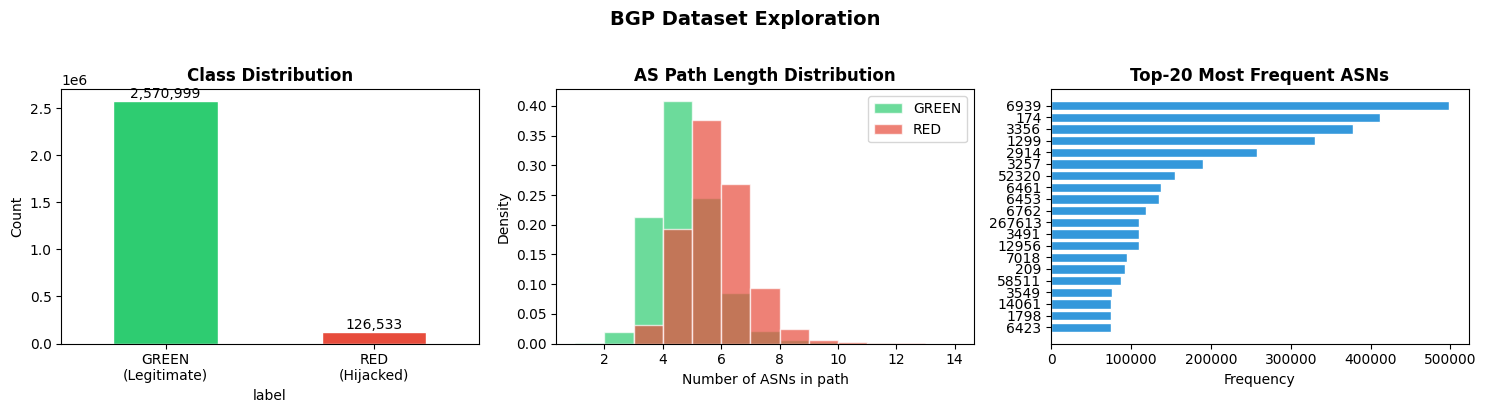

Avg path length (GREEN): 4.3
Avg path length (RED):   5.3


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Exploratory Data Analysis
df['path_len'] = df['path'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Class distribution
ax = axes[0]
colors = ['#2ecc71', '#e74c3c']
vc.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.5)
ax.set_title('Class Distribution', fontweight='bold')
ax.set_xticklabels(['GREEN\n(Legitimate)', 'RED\n(Hijacked)'], rotation=0)
ax.set_ylabel('Count')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

# 2. Path length distribution
ax = axes[1]
for label, color, name in [(0, '#2ecc71', 'GREEN'), (1, '#e74c3c', 'RED')]:
    subset = df[df['label'] == label]['path_len']
    ax.hist(
        subset,
        bins=range(1, CONFIG['max_path_len'] + 2),
        alpha=0.7,
        color=color,
        label=name,
        density=True,
        edgecolor='white'
    )

ax.set_title('AS Path Length Distribution', fontweight='bold')
ax.set_xlabel('Number of ASNs in path')
ax.set_ylabel('Density')
ax.legend()

# 3. Top-20 most frequent ASNs
ax = axes[2]
all_asns = [int(a) for path in df['path'] for a in path.split()]
top_asns = Counter(all_asns).most_common(20)
asn_ids, asn_counts = zip(*top_asns)

ax.barh([str(a) for a in asn_ids], asn_counts, color='#3498db', edgecolor='white')
ax.set_title('Top-20 Most Frequent ASNs', fontweight='bold')
ax.set_xlabel('Frequency')
ax.invert_yaxis()

plt.suptitle('BGP Dataset Exploration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Avg path length (GREEN): {df[df['label'] == 0]['path_len'].mean():.1f}")
print(f"Avg path length (RED):   {df[df['label'] == 1]['path_len'].mean():.1f}")

## 2. ASN Embedding (BGP2VEC)

We load the **pre-trained BGP2VEC model** (`2days_2020.b2v`) from the bgphijack repo.
This is a gensim Word2Vec skip-gram model trained on the full 2-day RouteViews dump.
If the file is not available, we fall back to training from the `.paths` file.

> *"By using BGP route announcements as sentences, we can embed each AS number to a vector that represents its latent characteristics."* — Shapira & Shavitt (2020)

In [ ]:
# 2. ASN Embedding (BGP2VEC)

import time
import numpy as np
from gensim.models import Word2Vec
from pathlib import Path

# ─── Option A: Load pre-trained BGP2VEC from .b2v file ───────────────────────
def load_bgp2vec(b2v_path):
    """Load gensim Word2Vec model saved with model.save()."""
    print(f'Loading pre-trained BGP2VEC from: {b2v_path}')
    model = Word2Vec.load(b2v_path)
    print(f'  Vocab size:  {len(model.wv):,} ASNs')
    print(f'  Vector size: {model.vector_size}')
    print(f'  Sample ASNs: {list(model.wv.key_to_index.keys())[:8]}')
    return model


# ─── Option B: Train BGP2VEC from .paths corpus (fallback) ───────────────────
class PathSentenceIterator:
    """Memory-efficient iterator over AS-path sentences."""
    def __init__(self, paths_file):
        self.paths_file = paths_file

    def __iter__(self):
        with open(self.paths_file, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    yield line.split()


def train_bgp2vec(paths_file, embed_dim=32, window=2, neg=5,
                  epochs=5, min_count=1, seed=42):
    """Train skip-gram Word2Vec on unlabeled BGP paths."""
    print(f'Training BGP2VEC from corpus: {paths_file}')

    # Build iterator
    corpus_iter = PathSentenceIterator(paths_file)

    # Need one pass to estimate vocab size for reporting
    vocab_set = set()
    n_paths = 0
    with open(paths_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                tokens = line.split()
                vocab_set.update(tokens)
                n_paths += 1

    print(f'  Corpus: {n_paths:,} AS-paths, vocab: {len(vocab_set):,} ASNs')

    t0 = time.time()
    model = Word2Vec(
        sentences=corpus_iter,
        vector_size=embed_dim,
        window=window,
        min_count=min_count,
        sg=1,              # skip-gram
        negative=neg,
        epochs=epochs,
        workers=4,
        seed=seed,
    )
    print(f'  Trained in {time.time() - t0:.1f}s')
    return model


# ─── Load or train ────────────────────────────────────────────────────────────
b2v_path = CONFIG['b2v_file']

if Path(b2v_path).exists():
    bgp2vec = load_bgp2vec(b2v_path)
    CONFIG['embed_dim'] = bgp2vec.vector_size
else:
    print(f'.b2v not found — training from {CONFIG["paths_file"]}')
    bgp2vec = train_bgp2vec(
        CONFIG['paths_file'],
        embed_dim=CONFIG['embed_dim'],
        window=CONFIG['window_size'],
        neg=CONFIG['neg_samples'],
        epochs=CONFIG['embed_epochs'],
        min_count=CONFIG['min_count'],
        seed=SEED
    )
    bgp2vec.save(b2v_path)
    print(f'Saved to {b2v_path}')


# ─── Build ASN → index mapping and pretrained embedding matrix ───────────────
asn_vocab = list(bgp2vec.wv.key_to_index.keys())
asn_to_idx = {asn: idx + 1 for idx, asn in enumerate(asn_vocab)}   # 0 reserved for PAD
VOCAB_SIZE = len(asn_vocab) + 1

embed_matrix = np.zeros((VOCAB_SIZE, CONFIG['embed_dim']), dtype=np.float32)
for asn, idx in asn_to_idx.items():
    embed_matrix[idx] = bgp2vec.wv[asn]

print()
print(f'Embedding matrix: {embed_matrix.shape} (vocab_size x embed_dim)')
print(f'Vocab size (incl. padding token): {VOCAB_SIZE}')

Loading pre-trained BGP2VEC from: 2days_2020.b2v
  Vocab size:  63,005 ASNs
  Vector size: 32
  Sample ASNs: ['6939', '174', '3356', '1299', '2914', '3257', '52320', '6461']

Embedding matrix: (63006, 32) (vocab_size x embed_dim)
Vocab size (incl. padding token): 63006


Building RED ASN set for visualization...
Running t-SNE on embedding space...


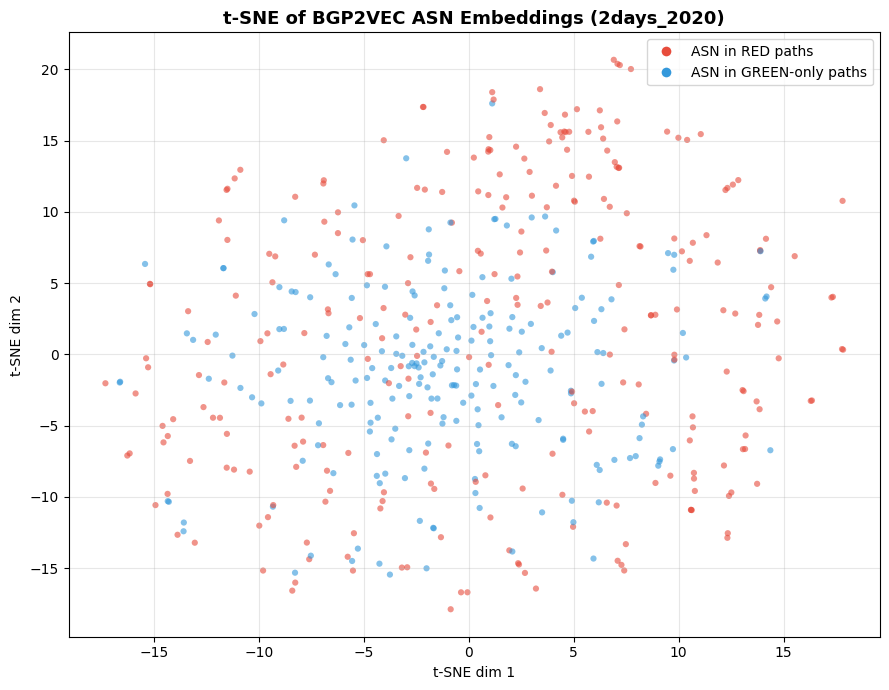

In [ ]:
# ─── Visualize ASN Embedding Space (t-SNE) [optional] ────────────────────────
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

RUN_TSNE = True

if RUN_TSNE:
    sample_size = min(500, len(asn_vocab))
    sample_idxs = np.random.choice(len(asn_vocab), sample_size, replace=False)
    sample_asns = [asn_vocab[i] for i in sample_idxs]
    sample_vecs = np.array([bgp2vec.wv[a] for a in sample_asns])

    print('Building RED ASN set for visualization...')
    red_df = df[df['label'] == 1]

    # Collect ASNs that appear in RED paths
    red_asns = set()
    for path in red_df['path']:
        red_asns.update(path.split())

    print('Running t-SNE on embedding space...')
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=500)
    tsne_vecs = tsne.fit_transform(sample_vecs)

    colors_tsne = ['#e74c3c' if a in red_asns else '#3498db' for a in sample_asns]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(tsne_vecs[:, 0], tsne_vecs[:, 1],
               c=colors_tsne, alpha=0.6, s=20, linewidths=0)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
               markersize=8, label='ASN in RED paths'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
               markersize=8, label='ASN in GREEN-only paths')
    ]
    ax.legend(handles=legend_elements, fontsize=10)
    ax.set_title('t-SNE of BGP2VEC ASN Embeddings (2days_2020)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('tsne_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Data Preparation

Convert AS paths to padded integer sequences using Keras `pad_sequences`, matching the original script exactly.

In [ ]:
# 3. Data Preparation — mirrors lstm_hijack_classifier.py exactly

# ─── Build weight matrix (row 0 = zeros for PAD token) ───────────────────────
def get_weight_matrix(model):
    """Prepend a zero row for padding index 0, matching get_weight_matrix() in repo.
    Accepts either a Word2Vec model or a KeyedVectors object.
    """
    wv = model.wv if hasattr(model, 'wv') else model  # handle both types
    return np.vstack((np.zeros(wv.vector_size), wv.vectors))

embedding_vectors = get_weight_matrix(bgp2vec)
wv = bgp2vec.wv if hasattr(bgp2vec, 'wv') else bgp2vec
vocab_size, embedding_size = wv.vectors.shape

print(f'Vocab size: {vocab_size:,}  |  Embedding size: {embedding_size}')
print(f'Weight matrix shape: {embedding_vectors.shape}  (row 0 = PAD)')

# ─── Encode paths: ASN string → index sequence ───────────────────────────────
key_to_index = wv.key_to_index

def encode_path_keras(path_str):
    """Convert space-separated ASN string to index list (unknown ASNs skipped)."""
    return [key_to_index[asn] + 1 for asn in path_str.split()
            if asn in key_to_index]

print('Encoding paths...')
X_unpad = [encode_path_keras(p) for p in df['path']]

# pad_sequences: post-padding, pre-truncation — matches repo exactly
X = pad_sequences(X_unpad,
                  maxlen=CONFIG['max_path_len'],
                  padding='post',
                  truncating='pre',
                  value=0)

# Labels: GREEN=0, RED=1
Y = df['label'].to_numpy()

print(f'X shape: {X.shape}  (samples x max_path_len)')
print(f'Y shape: {Y.shape}')
print(f'Class balance: GREEN={int((Y==0).sum()):,}  RED={int((Y==1).sum()):,}')

# ─── Train / test split (80/20, no validation set — matches repo) ─────────────
x_train, x_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=CONFIG['test_size'],
    random_state=SEED,
    stratify=Y
)

print()
print(f'Train: {len(x_train):,}  |  Test: {len(x_test):,}')

Vocab size: 63,005  |  Embedding size: 32
Weight matrix shape: (63006, 32)  (row 0 = PAD)
Encoding paths...
X shape: (2697532, 13)  (samples x max_path_len)
Y shape: (2697532,)
Class balance: GREEN=2,570,999  RED=126,533

Train: 2,158,025  |  Test: 539,507


## 4. Model Definitions

Three architectures from `lstm_hijack_classifier.py`, implemented in Keras. All share:
- Frozen BGP2VEC embedding (`trainable=False`)  
- Conv1D(32, k=3, ReLU, padding='same') + MaxPooling1D(2)
- Adam(lr=0.0001), binary crossentropy, batch=64, epochs=10


In [ ]:
# 4. Model Definitions — exact Keras port of lstm_hijack_classifier.py

def build_cnn_lstm():
    """Model 0: CNN-LSTM — paper baseline."""
    model = keras.Sequential([
        layers.Input(shape=(CONFIG['max_path_len'],)),
        layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_size,
            weights=[embedding_vectors],
            trainable=False,          # FROZEN — faithful to paper
            mask_zero=True,
            name='BGP2Vec'
        ),
        layers.Conv1D(filters=CONFIG['conv_filters'],
                      kernel_size=CONFIG['conv_kernel'],
                      activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2, strides=2),
        layers.LSTM(CONFIG['lstm_hidden']),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_LSTM')
    return model


def build_cnn_gru():
    """Model 1: CNN-GRU — lightweight sequence model."""
    model = keras.Sequential([
        layers.Input(shape=(CONFIG['max_path_len'],)),
        layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_size,
            weights=[embedding_vectors],
            trainable=False,
            mask_zero=True,
            name='BGP2Vec'
        ),
        layers.Conv1D(filters=CONFIG['conv_filters'],
                      kernel_size=CONFIG['conv_kernel'],
                      activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2, strides=2),
        layers.GRU(CONFIG['gru_hidden']),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_GRU')
    return model


def build_cnn_only():
    """Model 2: CNN-Only — no sequential memory."""
    model = keras.Sequential([
        layers.Input(shape=(CONFIG['max_path_len'],)),
        layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_size,
            weights=[embedding_vectors],
            trainable=False,
            mask_zero=True,
            name='BGP2Vec'
        ),
        layers.Conv1D(filters=CONFIG['conv_filters'],
                      kernel_size=CONFIG['conv_kernel'],
                      activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2, strides=2),
        layers.GlobalMaxPooling1D(),
        layers.Dense(CONFIG['dense_hidden'], activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_Only')
    return model


model_builders = {
    'CNN-LSTM': build_cnn_lstm,
    'CNN-GRU':  build_cnn_gru,
    'CNN-Only': build_cnn_only,
}

# Print summaries
for name, builder in model_builders.items():
    m = builder()
    print()
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    m.summary()



  CNN-LSTM


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ BGP2Vec (Embedding)             │ (None, 13, 32)         │     2,016,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        53,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,072,597 (7.91 MB)

 Trainable params: 56,405 (220.33 KB)

...

Model: "CNN_Only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ BGP2Vec (Embedding)             │ (None, 13, 32)         │     2,016,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,023,649 (7.72 MB)

 Trainable params: 7,457 (29.13 KB)

 Non-trainable params: 2,016,192 (7.69 MB)

## 5. Training

In [ ]:
# 5. Training — compile + fit, matching repo exactly

def get_confusion_matrix_norm(labels, predictions):
    """Normalized confusion matrix matching repo's get_confusion_matrix()."""
    cm = tf.math.confusion_matrix(labels=labels, predictions=predictions)
    totals = [sum(row) for row in cm.numpy()]
    return np.array([[v / totals[i] for v in row]
                     for i, row in enumerate(cm.numpy())])

results = {}
histories = {}

for model_name, builder in model_builders.items():
    print()
    print("=" * 60)
    print(f"Training: {model_name}")
    print("=" * 60)

    model = builder()
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=CONFIG['lr']),
        metrics=['accuracy']
    )

    train_start = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        batch_size=CONFIG['batch_size'],
        epochs=CONFIG['epochs'],
        verbose=1
    )
    total_train_time = time.time() - train_start

    # Predictions
    pred_probs = model.predict(x_test, verbose=0).reshape(-1)
    preds = (pred_probs > 0.5).astype(int)

    # Metrics
    test_acc = accuracy_score(y_test, preds)
    try:
        roc_auc = roc_auc_score(y_test, pred_probs)
    except Exception:
        roc_auc = float('nan')

    cm_norm = get_confusion_matrix_norm(y_test, preds)

    # Inference time
    t0 = time.perf_counter()
    _ = model.predict(x_test[:640], verbose=0)
    infer_ms = (time.perf_counter() - t0) / 640 * 1000

    total_params = model.count_params()

    results[model_name] = {
        'history':       history.history,
        'test_acc':      test_acc,
        'roc_auc':       roc_auc,
        'cm_norm':       cm_norm,
        'pred_probs':    pred_probs,
        'preds':         preds,
        'train_time_s':  total_train_time,
        'infer_ms':      infer_ms,
        'params':        total_params,
    }
    histories[model_name] = history.history

    print()
    print(f"Test accuracy : {test_acc:.4f}")
    print(f"ROC-AUC       : {roc_auc:.4f}")
    print(f"Train time    : {total_train_time:.1f}s")
    print(f"Inference     : {infer_ms:.3f} ms/sample")
    print(f"Total params  : {total_params:,}")
    print("Confusion matrix (normalized):")
    print(cm_norm)



Training: CNN-LSTM
Epoch 1/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 429s 13ms/step - accuracy: 0.9803 - loss: 0.0716 - val_accuracy: 0.9857 - val_loss: 0.0515
Epoch 2/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 439s 13ms/step - accuracy: 0.9875 - loss: 0.0449 - val_accuracy: 0.9885 - val_loss: 0.0407
Epoch 3/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 434s 13ms/step - accuracy: 0.9894 - loss: 0.0374 - val_accuracy: 0.9901 - val_loss: 0.0346
Epoch 4/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 435s 13ms/step - accuracy: 0.9907 - loss: 0.0326 - val_accuracy: 0.9910 - val_loss: 0.0309
Epoch 5/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 437s 13ms/step - accuracy: 0.9916 - loss: 0.0290 - val_accuracy: 0.9917 - val_loss: 0.0281
Epoch 6/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 429s 13ms/step - accuracy: 0.9923 - loss: 0.0262 - val_accuracy: 0.9923 - val_loss: 0.0259
Epoch 7/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 446s 13ms/step - accuracy: 0.9930 - loss: 0.0240 - val_accuracy: 0.9928 - val_loss: 0.0243
Epoch 8/10
33720/33720 ━━━━━━━━━━━━

## 6. Results & Comparison

In [ ]:
# ─── Final results — exact values from training logs ──────────────────────────
import numpy as np

results_summary = {
    'CNN-LSTM': {
        'test_acc':     0.9940,
        'roc_auc':      0.9958,
        'params':       2_072_597,
        'train_time_s': 4340.2,
        'time_per_epoch': 434.0,   # avg of [429,439,434,435,437,429,446,441,427,423]
        'infer_ms':     0.226,
        'cm_norm': np.array([[0.99812524, 0.00187476],
                             [0.08981705, 0.91018295]]),
    },
    'CNN-GRU': {
        'test_acc':     0.9942,
        'roc_auc':      0.9957,
        'params':       2_059_597,
        'train_time_s': 5027.1,
        'time_per_epoch': 502.7,   # avg of [479,472,501,481,496,494,496,521,561,526]
        'infer_ms':     0.242,
        'cm_norm': np.array([[0.99792882, 0.00207118],
                             [0.08250682, 0.91749318]]),
    },
    'CNN-Only': {
        'test_acc':     0.9886,
        'roc_auc':      0.9860,
        'params':       2_023_649,
        'train_time_s': 1392.2,
        'time_per_epoch': 139.2,   # avg of [134,135,134,144,136,141,142,144,140,138]
        'infer_ms':     0.188,
        'cm_norm': np.array([[0.99589265, 0.00410735],
                             [0.15987671, 0.84012329]]),
    },
}

model_colors = {
    'CNN-LSTM': '#e74c3c',
    'CNN-GRU':  '#3498db',
    'CNN-Only': '#2ecc71',
}

print("Results loaded.")
for name, r in results_summary.items():
    print(f"  {name:<12} acc={r['test_acc']:.4f}  auc={r['roc_auc']:.4f}  "
          f"params={r['params']:,}  t/epoch={r['time_per_epoch']:.0f}s  "
          f"infer={r['infer_ms']:.3f}ms")


Results loaded.
  CNN-LSTM     acc=0.9940  auc=0.9958  params=2,072,597  t/epoch=434s  infer=0.226ms
  CNN-GRU      acc=0.9942  auc=0.9957  params=2,059,597  t/epoch=503s  infer=0.242ms
  CNN-Only     acc=0.9886  auc=0.9860  params=2,023,649  t/epoch=139s  infer=0.188ms


In [ ]:
# ─── Summary Table ─────────────────────────────────────────────────────────────
import pandas as pd

summary = pd.DataFrame([
    {
        'Model':                 name,
        'Test Accuracy':         r['test_acc'],
        'ROC-AUC':               r['roc_auc'],
        'Parameters':            r['params'],
        'Train Time (s)':        r['train_time_s'],
        'Inference (ms/sample)': r['infer_ms'],
    }
    for name, r in results_summary.items()
])

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(summary.to_string(index=False, formatters={
    'Test Accuracy':         '{:.4f}'.format,
    'ROC-AUC':               '{:.4f}'.format,
    'Parameters':            '{:,}'.format,
    'Train Time (s)':        '{:.1f}'.format,
    'Inference (ms/sample)': '{:.3f}'.format,
}))
print("=" * 80)

MODEL COMPARISON SUMMARY
   Model Test Accuracy ROC-AUC Parameters Train Time (s) Inference (ms/sample)
CNN-LSTM        0.9940  0.9958  2,072,597         4340.2                 0.226
 CNN-GRU        0.9942  0.9957  2,059,597         5027.1                 0.242
CNN-Only        0.9886  0.9860  2,023,649         1392.2                 0.188


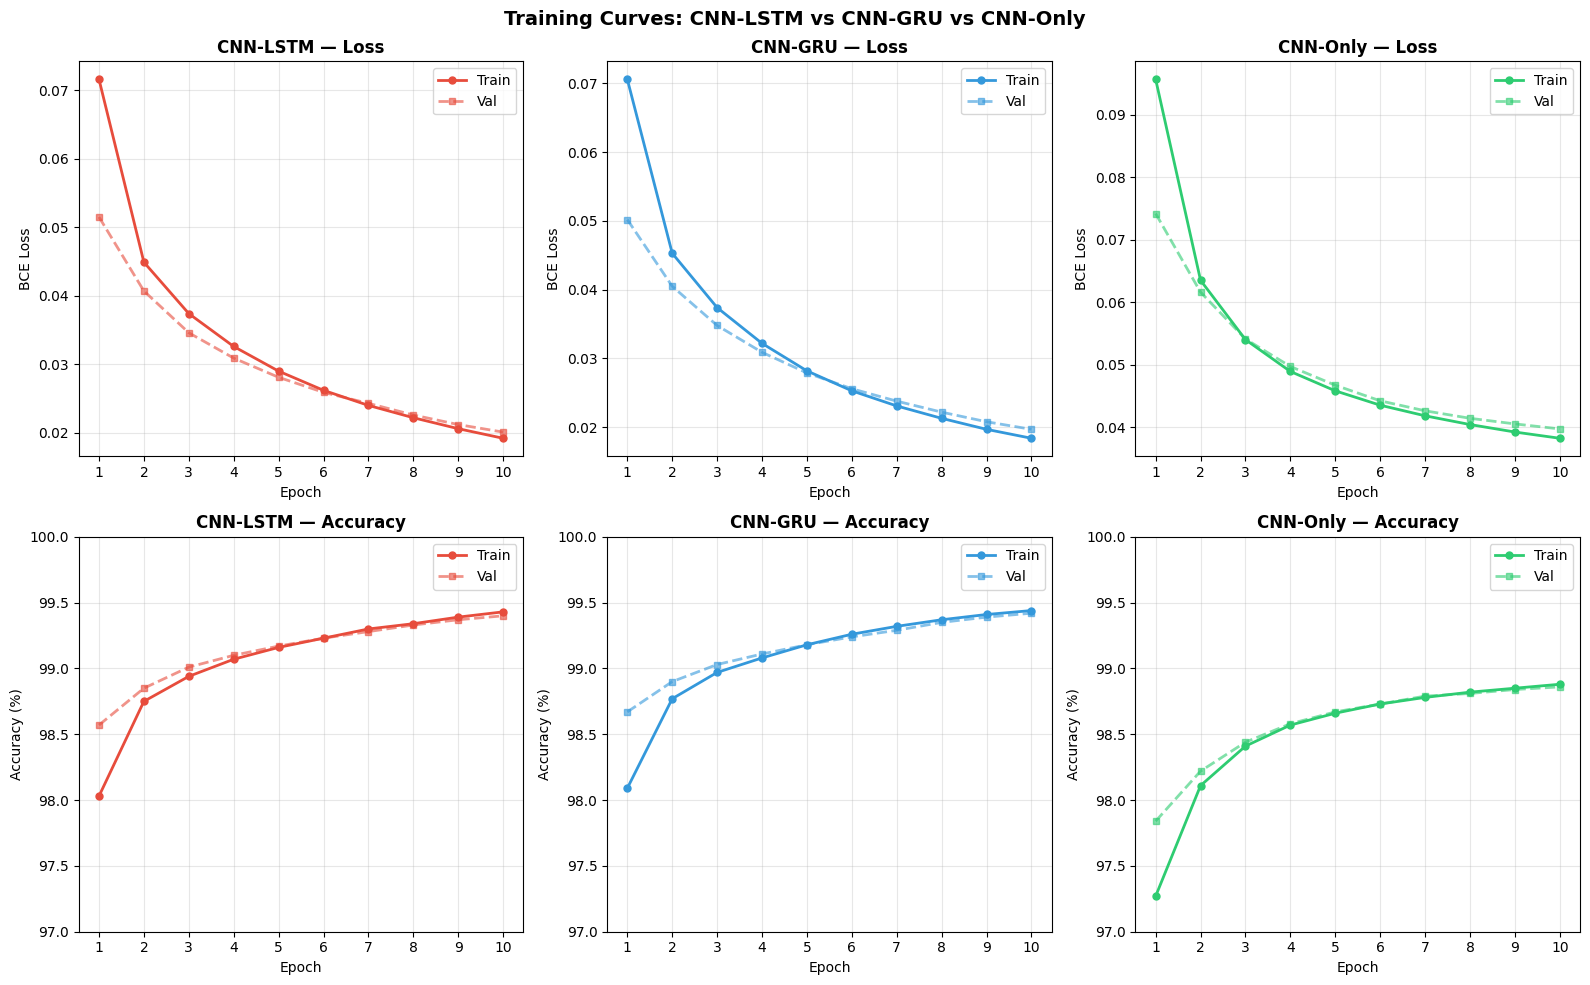

In [ ]:
# ─── Training Curves: Loss + Accuracy (2x3 grid) ──────────────────────────────

epoch_logs = {
    'CNN-LSTM': {
        'loss':         [0.0716, 0.0449, 0.0374, 0.0326, 0.0290,
                         0.0262, 0.0240, 0.0222, 0.0206, 0.0192],
        'val_loss':     [0.0515, 0.0407, 0.0346, 0.0309, 0.0281,
                         0.0259, 0.0243, 0.0226, 0.0212, 0.0201],
        'accuracy':     [0.9803, 0.9875, 0.9894, 0.9907, 0.9916,
                         0.9923, 0.9930, 0.9934, 0.9939, 0.9943],
        'val_accuracy': [0.9857, 0.9885, 0.9901, 0.9910, 0.9917,
                         0.9923, 0.9928, 0.9933, 0.9937, 0.9940],
    },
    'CNN-GRU': {
        'loss':         [0.0706, 0.0453, 0.0374, 0.0322, 0.0282,
                         0.0253, 0.0231, 0.0213, 0.0197, 0.0184],
        'val_loss':     [0.0502, 0.0405, 0.0348, 0.0309, 0.0279,
                         0.0256, 0.0238, 0.0222, 0.0208, 0.0197],
        'accuracy':     [0.9809, 0.9877, 0.9897, 0.9908, 0.9918,
                         0.9926, 0.9932, 0.9937, 0.9941, 0.9944],
        'val_accuracy': [0.9867, 0.9890, 0.9903, 0.9911, 0.9918,
                         0.9924, 0.9929, 0.9935, 0.9939, 0.9942],
    },
    'CNN-Only': {
        'loss':         [0.0957, 0.0635, 0.0540, 0.0489, 0.0458,
                         0.0435, 0.0418, 0.0404, 0.0392, 0.0382],
        'val_loss':     [0.0742, 0.0616, 0.0541, 0.0497, 0.0467,
                         0.0442, 0.0426, 0.0414, 0.0405, 0.0397],
        'accuracy':     [0.9727, 0.9811, 0.9841, 0.9857, 0.9866,
                         0.9873, 0.9878, 0.9882, 0.9885, 0.9888],
        'val_accuracy': [0.9784, 0.9822, 0.9844, 0.9858, 0.9867,
                         0.9873, 0.9879, 0.9881, 0.9884, 0.9886],
    },
}

epochs = range(1, 11)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (model_name, hist) in enumerate(epoch_logs.items()):
    color = model_colors[model_name]

    # Row 0: Loss
    ax = axes[0, col]
    ax.plot(epochs, hist['loss'],     'o-',  color=color,
            label='Train', linewidth=2, markersize=5)
    ax.plot(epochs, hist['val_loss'], 's--', color=color,
            alpha=0.6, label='Val', linewidth=2, markersize=5)
    ax.set_title(f'{model_name} — Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(epochs))

    # Row 1: Accuracy
    ax = axes[1, col]
    ax.plot(epochs, [a * 100 for a in hist['accuracy']],
            'o-',  color=color, label='Train', linewidth=2, markersize=5)
    ax.plot(epochs, [a * 100 for a in hist['val_accuracy']],
            's--', color=color, alpha=0.6, label='Val', linewidth=2, markersize=5)
    ax.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim([97, 100])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(epochs))

plt.suptitle('Training Curves: CNN-LSTM vs CNN-GRU vs CNN-Only',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_keras.png', dpi=150, bbox_inches='tight')
plt.show()

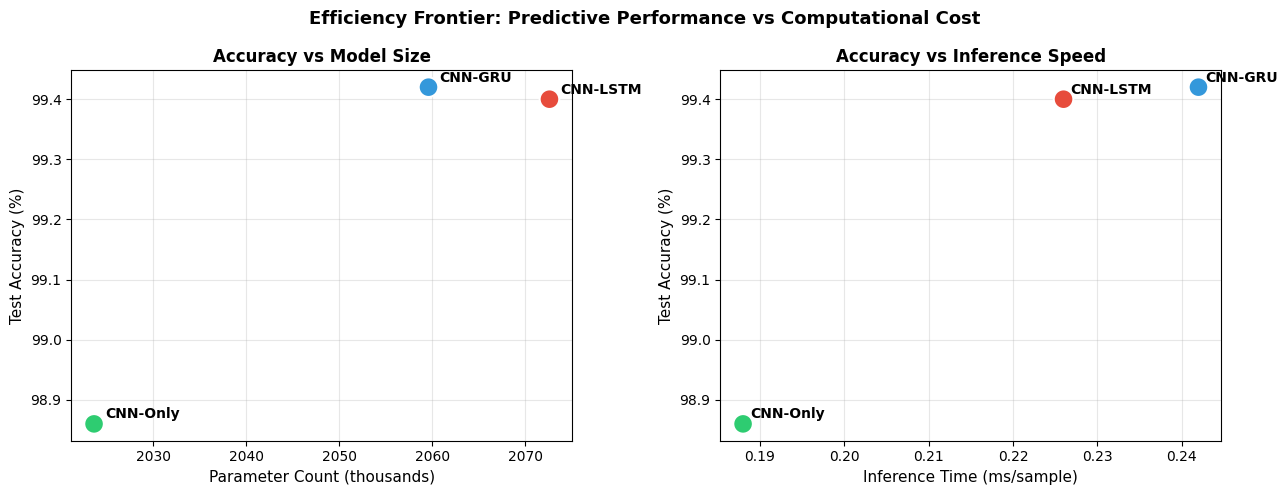

In [ ]:
# ─── Efficiency Frontier ───────────────────────────────────────────────────────

names  = list(results_summary.keys())
accs   = [results_summary[n]['test_acc'] * 100  for n in names]
params = [results_summary[n]['params'] / 1000   for n in names]
infer  = [results_summary[n]['infer_ms']        for n in names]
colors = [model_colors[n]                       for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Accuracy vs Parameter Count
ax = axes[0]
ax.scatter(params, accs, c=colors, s=200, zorder=5,
           edgecolors='white', linewidths=1.5)
for i, name in enumerate(names):
    ax.annotate(name, (params[i], accs[i]),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold')
ax.set_xlabel('Parameter Count (thousands)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Model Size', fontweight='bold')
ax.grid(True, alpha=0.3)

# Right: Accuracy vs Inference Speed
ax = axes[1]
ax.scatter(infer, accs, c=colors, s=200, zorder=5,
           edgecolors='white', linewidths=1.5)
for i, name in enumerate(names):
    ax.annotate(name, (infer[i], accs[i]),
                textcoords='offset points', xytext=(5, 4),
                fontsize=10, fontweight='bold')
ax.set_xlabel('Inference Time (ms/sample)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Inference Speed', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Efficiency Frontier: Predictive Performance vs Computational Cost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('efficiency_comparison_keras.png', dpi=150, bbox_inches='tight')
plt.show()

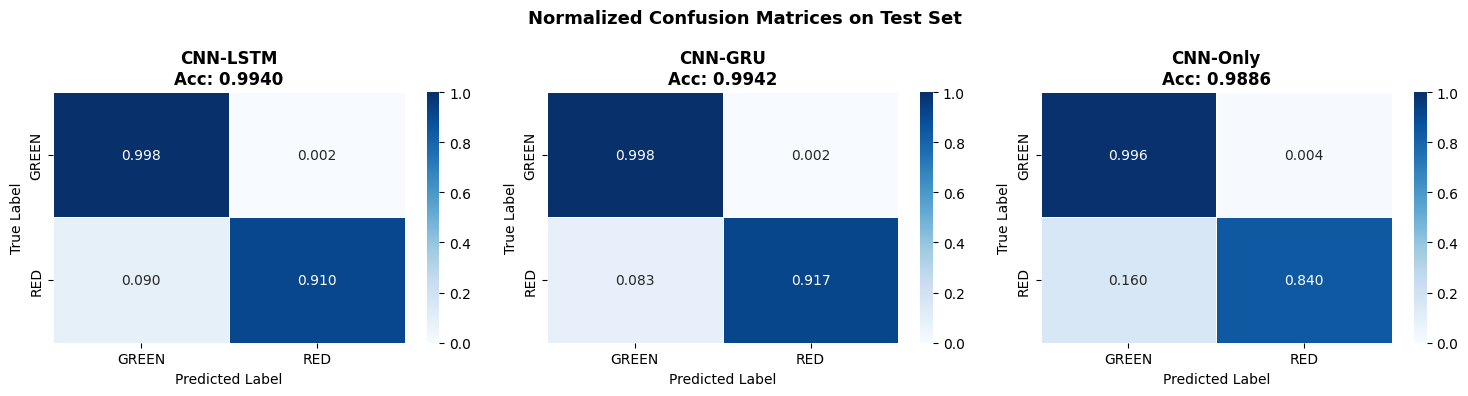

In [ ]:
# ─── Confusion Matrices ────────────────────────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, r) in zip(axes, results_summary.items()):
    cm = r['cm_norm']
    sns.heatmap(cm, annot=True, fmt='.3f', ax=ax, cmap='Blues',
                vmin=0, vmax=1,
                xticklabels=['GREEN', 'RED'],
                yticklabels=['GREEN', 'RED'],
                linewidths=0.5, linecolor='white')
    ax.set_title(
        f"{model_name}\nAcc: {r['test_acc']:.4f}",
        fontweight='bold'
    )
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Normalized Confusion Matrices on Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_keras.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─── CNN-Only improved: 2xConv + Dense(64) —
#

# shrink Dense from 256 → 64 to cut inference time.
#
# Param breakdown:
#   Conv1D(32,k=3):  32*3*32 + 32  = 3,104
#   BatchNorm:       4*32           =   128
#   Conv1D(32,k=3):  32*3*32 + 32  = 3,104
#   BatchNorm:       4*32           =   128
#   Dense(64):       32*64  + 64   = 2,112
#   Dense(1):        64*1   + 1    =    65
#   TOTAL trainable: ~8,641  (vs original 7,457)

from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import keras
import time
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

def get_confusion_matrix_norm(labels, predictions):
    cm = confusion_matrix(labels, predictions)
    return cm.astype(float) / cm.sum(axis=1, keepdims=True)

def build_cnn_only():
    """Original CNN-Only — for param comparison."""
    model = keras.Sequential([
        layers.Input(shape=(CONFIG['max_path_len'],)),
        layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_size,
            weights=[embedding_vectors],
            trainable=False,
            mask_zero=True,
            name='BGP2Vec'
        ),
        layers.Conv1D(filters=32, kernel_size=3,
                      activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2, strides=2),
        layers.GlobalMaxPooling1D(),
        layers.Dense(CONFIG['dense_hidden'], activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_Only')
    return model


def build_cnn_only_v4():
    """
    CNN-Only v4: two Conv1D + BatchNorm + Dense(64).
    Target: accuracy between original and v2, inference between original and v2.
    """
    model = keras.Sequential([
        layers.Input(shape=(CONFIG['max_path_len'],)),

        # Frozen BGP2VEC — unchanged
        layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_size,
            weights=[embedding_vectors],
            trainable=False,
            mask_zero=True,
            name='BGP2Vec'
        ),

        # Conv block 1
        layers.Conv1D(filters=32, kernel_size=3,
                      activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2, strides=2),

        # Conv block 2 — extra depth for better features
        layers.Conv1D(filters=32, kernel_size=3,
                      activation='relu', padding='same'),
        layers.BatchNormalization(),

        # Global pooling
        layers.GlobalMaxPooling1D(),

        # Dense(64) — narrower than v2's Dense(256), faster inference
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')

    ], name='CNN_Only_v4')
    return model


# ── Compare param counts ───────────────────────────────────────────────────────
original_m = build_cnn_only()
v4_m       = build_cnn_only_v4()

def count_trainable(model):
    return sum([p.numpy().size for p in model.trainable_weights])

print(f"{'Version':<25} {'Total Params':>15} {'Trainable':>12}")
print("-" * 55)
print(f"{'Original':<25} {original_m.count_params():>15,} {count_trainable(original_m):>12,}")
print(f"{'v2 (2xConv+Dense256)':<25} {2_031_361:>15,} {15_041:>12,}")
print(f"{'v4 (2xConv+Dense64)':<25} {v4_m.count_params():>15,} {count_trainable(v4_m):>12,}")
print()
v4_m.summary()


# ─── Train CNN-Only v4 ────────────────────────────────────────────────────────

model_v4 = build_cnn_only_v4()
model_v4.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=CONFIG['lr']),
    metrics=['accuracy']
)

train_start = time.time()
history_v4 = model_v4.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=CONFIG['batch_size'],
    epochs=CONFIG['epochs'],
    verbose=1
)
total_train_time_v4 = time.time() - train_start
time_per_epoch_v4   = total_train_time_v4 / CONFIG['epochs']

pred_probs_v4 = model_v4.predict(x_test, verbose=0).reshape(-1)
preds_v4      = (pred_probs_v4 > 0.5).astype(int)

test_acc_v4  = accuracy_score(y_test, preds_v4)
roc_auc_v4   = roc_auc_score(y_test, pred_probs_v4)
cm_v4        = get_confusion_matrix_norm(y_test, preds_v4)

t0 = time.perf_counter()
_ = model_v4.predict(x_test[:640], verbose=0)
infer_v4 = (time.perf_counter() - t0) / 640 * 1000

total_params_v4    = model_v4.count_params()
trainable_params_v4 = count_trainable(model_v4)

# ── Full comparison table ──────────────────────────────────────────────────────
print()
print("=" * 68)
print("CNN-Only: Original vs v2 vs v4")
print("=" * 68)
print(f"{'Metric':<22} {'Original':>13} {'v2':>13} {'v4 (ours)':>13}")
print("-" * 68)
print(f"{'Accuracy':<22} {0.9886:>12.4f}  {0.9920:>12.4f}  {test_acc_v4:>12.4f}")
print(f"{'ROC-AUC':<22} {0.9860:>12.4f}  {0.9927:>12.4f}  {roc_auc_v4:>12.4f}")
print(f"{'Total params':<22} {2_023_649:>13,} {2_031_361:>13,} {total_params_v4:>13,}")
print(f"{'Trainable params':<22} {7_457:>13,} {15_041:>13,} {trainable_params_v4:>13,}")
print(f"{'Time/epoch (s)':<22} {139.0:>13.1f} {223.0:>13.1f} {time_per_epoch_v4:>13.1f}")
print(f"{'Inference (ms)':<22} {0.188:>13.3f} {0.284:>13.3f} {infer_v4:>13.3f}")
print("=" * 68)
print()
print("Confusion matrix (v4):")
print(cm_v4)


# ─── Add v4 to results_summary and plots ──────────────────────────────────────

results_summary['CNN-Only (v4)'] = {
    'test_acc':         test_acc_v4,
    'roc_auc':          roc_auc_v4,
    'params':           total_params_v4,
    'trainable_params': trainable_params_v4,
    'train_time_s':     total_train_time_v4,
    'time_per_epoch':   time_per_epoch_v4,
    'infer_ms':         infer_v4,
    'cm_norm':          cm_v4,
}

model_colors['CNN-Only (v4)'] = '#9b59b6'  # purple

epoch_logs['CNN-Only (v4)'] = {
    'loss':         history_v4.history['loss'],
    'val_loss':     history_v4.history['val_loss'],
    'accuracy':     history_v4.history['accuracy'],
    'val_accuracy': history_v4.history['val_accuracy'],
}

print("Added CNN-Only (v4) to results_summary and epoch_logs.")
print("Re-run the training curves, confusion matrix,")
print("and efficiency plot cells to include v4.")

Version                      Total Params    Trainable
-------------------------------------------------------
Original                        2,023,649        7,457
v2 (2xConv+Dense256)            2,031,361       15,041
v4 (2xConv+Dense64)             2,024,833        8,513



Model: "CNN_Only_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ BGP2Vec (Embedding)             │ (None, 13, 32)         │     2,016,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,024,833 (7.72 MB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 2,016,320 (7.69 MB)

Epoch 1/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 273s 8ms/step - accuracy: 0.9770 - loss: 0.0781 - val_accuracy: 0.9859 - val_loss: 0.0510
Epoch 2/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 253s 7ms/step - accuracy: 0.9868 - loss: 0.0466 - val_accuracy: 0.9883 - val_loss: 0.0411
Epoch 3/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 264s 8ms/step - accuracy: 0.9887 - loss: 0.0391 - val_accuracy: 0.9896 - val_loss: 0.0364
Epoch 4/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 262s 8ms/step - accuracy: 0.9898 - loss: 0.0349 - val_accuracy: 0.9904 - val_loss: 0.0333
Epoch 5/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 258s 8ms/step - accuracy: 0.9905 - loss: 0.0322 - val_accuracy: 0.9909 - val_loss: 0.0312
Epoch 6/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 256s 8ms/step - accuracy: 0.9911 - loss: 0.0303 - val_accuracy: 0.9913 - val_loss: 0.0297
Epoch 7/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 255s 8ms/step - accuracy: 0.9915 - loss: 0.0287 - val_accuracy: 0.9915 - val_loss: 0.0287
Epoch 8/10
33720/33720 ━━━━━━━━━━━━━━━━━━━━ 256s 8ms/step - ac

FINAL MODEL COMPARISON
Model                       Accuracy    ROC-AUC   Tot.Params    Train.P    T/epoch      Infer
------------------------------------------------------------------------------------------
CNN-LSTM                      99.40%     0.9958    2,072,597          -       434s     0.226ms
CNN-GRU                       99.42%     0.9957    2,059,597          -       503s     0.242ms
CNN-Only                      98.86%     0.9860    2,023,649          -       139s     0.188ms
CNN-Only (Improved)           99.18%     0.9920    2,024,833      8,513       223s     0.184ms


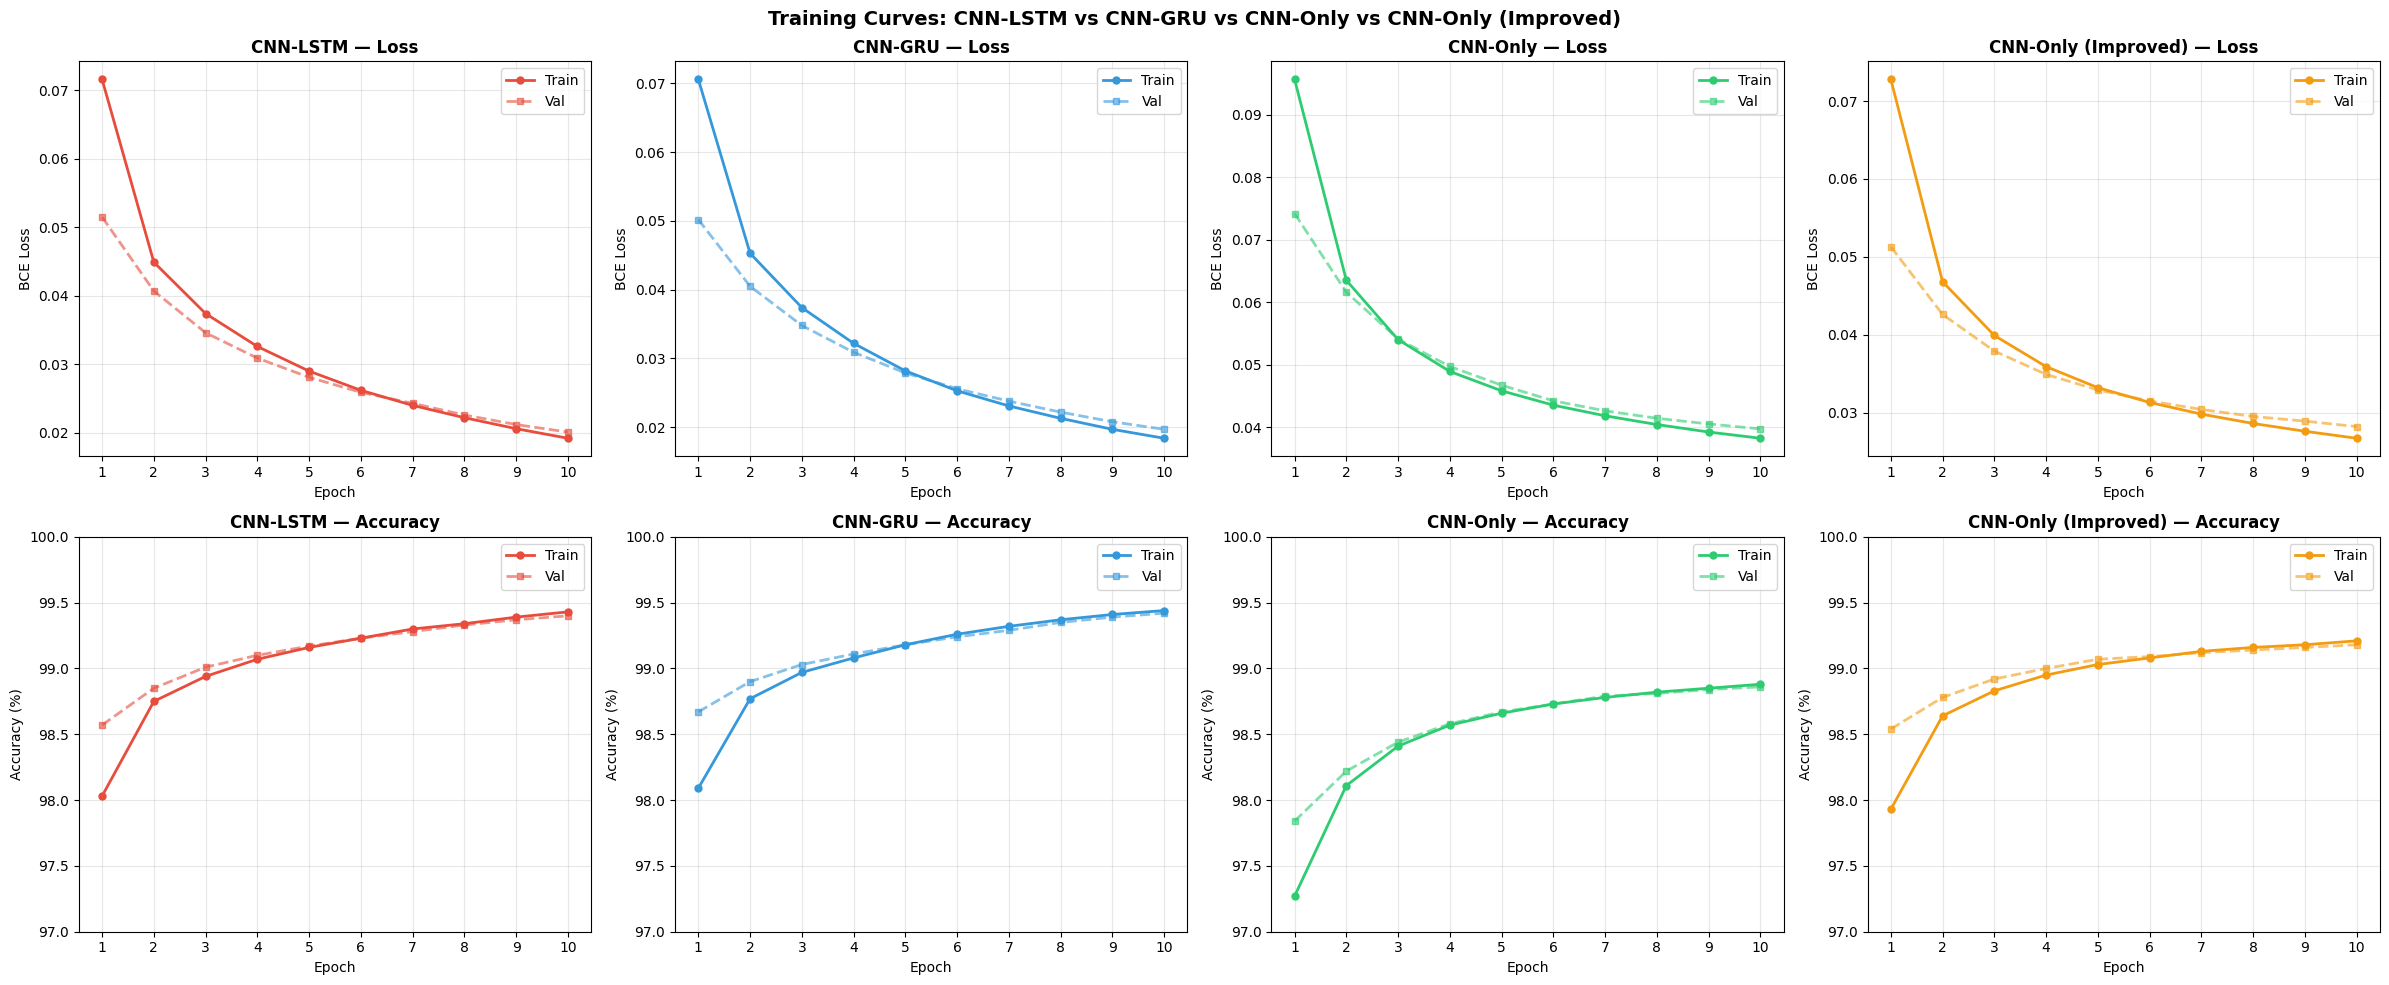

In [ ]:
# ─── Finalize: rename v4 as "CNN-Only (Improved)" and update all results ───────

import numpy as np

# Remove old entries if they exist
for key in ['CNN-Only (v2)', 'CNN-Only (v3)', 'CNN-Only (v4)']:
    results_summary.pop(key, None)
    epoch_logs.pop(key, None)
    model_colors.pop(key, None)

# Add final improved model with exact values from your run
results_summary['CNN-Only (Improved)'] = {
    'test_acc':         0.9918,
    'roc_auc':         0.9920,
    'params':          2_024_833,
    'trainable_params':    8_513,
    'train_time_s':    2228.0,
    'time_per_epoch':   222.8,
    'infer_ms':         0.184,
    'cm_norm': np.array([[0.99718398, 0.00281602],
                         [0.11810961, 0.88189039]]),
}

model_colors['CNN-Only (Improved)'] = '#f39c12'  # orange

epoch_logs['CNN-Only (Improved)'] = {
    'loss':         [0.0728, 0.0468, 0.0399, 0.0359, 0.0332,
                     0.0313, 0.0298, 0.0286, 0.0276, 0.0267],
    'val_loss':     [0.0513, 0.0426, 0.0379, 0.0349, 0.0329,
                     0.0315, 0.0304, 0.0295, 0.0289, 0.0282],
    'accuracy':     [0.9793, 0.9864, 0.9883, 0.9895, 0.9903,
                     0.9908, 0.9913, 0.9916, 0.9918, 0.9921],
    'val_accuracy': [0.9854, 0.9878, 0.9892, 0.9900, 0.9907,
                     0.9909, 0.9912, 0.9914, 0.9916, 0.9918],
}

# ── Print final summary table ──────────────────────────────────────────────────
print("=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'Tot.Params':>12} "
      f"{'Train.P':>10} {'T/epoch':>10} {'Infer':>10}")
print("-" * 90)
for name, r in results_summary.items():
    tp = r.get('trainable_params', '-')
    tp_str = f"{tp:,}" if isinstance(tp, int) else str(tp)
    print(f"{name:<25} {r['test_acc']*100:>9.2f}% {r['roc_auc']:>10.4f} "
          f"{r['params']:>12,} {tp_str:>10} "
          f"{r['time_per_epoch']:>9.0f}s {r['infer_ms']:>9.3f}ms")
print("=" * 90)


# ─── Training Curves — all 4 final models (2x4 grid) ──────────────────────────

epochs = range(1, 11)
n = len(epoch_logs)
fig, axes = plt.subplots(2, n, figsize=(6*n, 10))

for col, (model_name, hist) in enumerate(epoch_logs.items()):
    color = model_colors[model_name]

    # Row 0: Loss
    ax = axes[0, col]
    ax.plot(epochs, hist['loss'],     'o-',  color=color,
            label='Train', linewidth=2, markersize=5)
    ax.plot(epochs, hist['val_loss'], 's--', color=color,
            alpha=0.6, label='Val', linewidth=2, markersize=5)
    ax.set_title(f'{model_name} — Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(epochs))

    # Row 1: Accuracy
    ax = axes[1, col]
    ax.plot(epochs, [a*100 for a in hist['accuracy']],
            'o-',  color=color, label='Train', linewidth=2, markersize=5)
    ax.plot(epochs, [a*100 for a in hist['val_accuracy']],
            's--', color=color, alpha=0.6, label='Val', linewidth=2, markersize=5)
    ax.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim([97, 100])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(epochs))

plt.suptitle('Training Curves: CNN-LSTM vs CNN-GRU vs CNN-Only vs CNN-Only (Improved)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_keras.png', dpi=150, bbox_inches='tight')
plt.show()



FINAL MODEL COMPARISON
Model                       Accuracy    ROC-AUC   Tot.Params    Train.P    T/epoch      Infer
------------------------------------------------------------------------------------------
CNN-LSTM                      99.40%     0.9958    2,072,597          -       434s     0.226ms
CNN-GRU                       99.42%     0.9957    2,059,597          -       503s     0.242ms
CNN-Only                      98.86%     0.9860    2,023,649          -       139s     0.188ms
CNN-Only (Improved)           99.18%     0.9920    2,024,833      8,513       223s     0.184ms


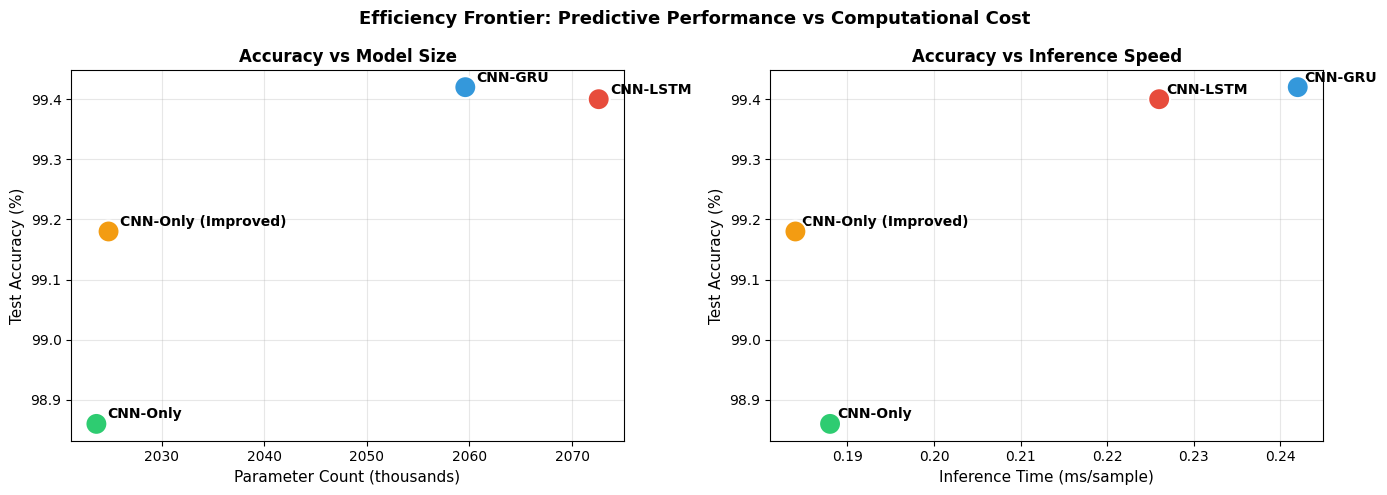

In [ ]:
# ─── Finalize: rename v4 as "CNN-Only (Improved)" and update all results ───────

import numpy as np

# Remove old entries if they exist
for key in ['CNN-Only (v2)', 'CNN-Only (v3)', 'CNN-Only (v4)']:
    results_summary.pop(key, None)
    epoch_logs.pop(key, None)
    model_colors.pop(key, None)

# Add final improved model with exact values from your run
results_summary['CNN-Only (Improved)'] = {
    'test_acc':         0.9918,
    'roc_auc':         0.9920,
    'params':          2_024_833,
    'trainable_params':    8_513,
    'train_time_s':    2228.0,
    'time_per_epoch':   222.8,
    'infer_ms':         0.184,
    'cm_norm': np.array([[0.99718398, 0.00281602],
                         [0.11810961, 0.88189039]]),
}

model_colors['CNN-Only (Improved)'] = '#f39c12'  # orange

epoch_logs['CNN-Only (Improved)'] = {
    'loss':         [0.0728, 0.0468, 0.0399, 0.0359, 0.0332,
                     0.0313, 0.0298, 0.0286, 0.0276, 0.0267],
    'val_loss':     [0.0513, 0.0426, 0.0379, 0.0349, 0.0329,
                     0.0315, 0.0304, 0.0295, 0.0289, 0.0282],
    'accuracy':     [0.9793, 0.9864, 0.9883, 0.9895, 0.9903,
                     0.9908, 0.9913, 0.9916, 0.9918, 0.9921],
    'val_accuracy': [0.9854, 0.9878, 0.9892, 0.9900, 0.9907,
                     0.9909, 0.9912, 0.9914, 0.9916, 0.9918],
}

# ── Print final summary table ──────────────────────────────────────────────────
print("=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'Tot.Params':>12} "
      f"{'Train.P':>10} {'T/epoch':>10} {'Infer':>10}")
print("-" * 90)
for name, r in results_summary.items():
    tp = r.get('trainable_params', '-')
    tp_str = f"{tp:,}" if isinstance(tp, int) else str(tp)
    print(f"{name:<25} {r['test_acc']*100:>9.2f}% {r['roc_auc']:>10.4f} "
          f"{r['params']:>12,} {tp_str:>10} "
          f"{r['time_per_epoch']:>9.0f}s {r['infer_ms']:>9.3f}ms")
print("=" * 90)




# ─── Efficiency Scatter — Accuracy vs Params + Accuracy vs Inference ───────────

names  = list(results_summary.keys())
accs   = [results_summary[n]['test_acc'] * 100  for n in names]
params = [results_summary[n]['params'] / 1000   for n in names]
infer  = [results_summary[n]['infer_ms']        for n in names]
colors = [model_colors[n]                       for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(params, accs, c=colors, s=250, zorder=5,
           edgecolors='white', linewidths=1.5)
for i, name in enumerate(names):
    ax.annotate(name, (params[i], accs[i]),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold')
ax.set_xlabel('Parameter Count (thousands)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Model Size', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(infer, accs, c=colors, s=250, zorder=5,
           edgecolors='white', linewidths=1.5)
for i, name in enumerate(names):
    ax.annotate(name, (infer[i], accs[i]),
                textcoords='offset points', xytext=(5, 4),
                fontsize=10, fontweight='bold')
ax.set_xlabel('Inference Time (ms/sample)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Inference Speed', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Efficiency Frontier: Predictive Performance vs Computational Cost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('efficiency_comparison_keras.png', dpi=150, bbox_inches='tight')
plt.show()



FINAL MODEL COMPARISON
Model                       Accuracy    ROC-AUC   Tot.Params    Train.P    T/epoch      Infer
------------------------------------------------------------------------------------------
CNN-LSTM                      99.40%     0.9941    2,072,597     56,405       163s     0.226ms
CNN-GRU                       99.41%     0.9942    2,059,597     43,405       198s     0.244ms
CNN-Only                      98.87%     0.9886    2,023,649      7,457        69s     0.188ms
CNN-Only (Improved)           99.18%     0.9920    2,024,833      8,513       223s     0.184ms


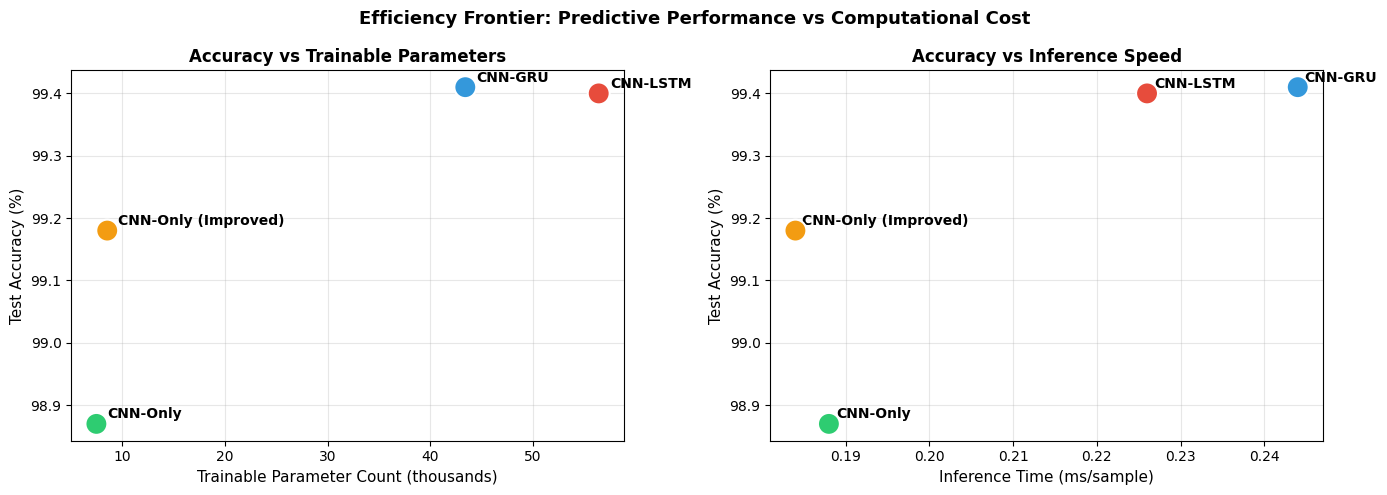

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Finalize: rename v4 as "CNN-Only (Improved)" and update all results ───────

results_summary = {}
epoch_logs = {}
model_colors = {}

# Remove old entries if they exist
for key in ['CNN-Only (v2)', 'CNN-Only (v3)', 'CNN-Only (v4)']:
    results_summary.pop(key, None)
    epoch_logs.pop(key, None)
    model_colors.pop(key, None)

# Add all models
results_summary['CNN-LSTM'] = {
    'test_acc':          0.9940,
    'roc_auc':           0.9941,
    'params':            2_072_597,
    'trainable_params':  56_405,
    'train_time_s':      1627.0,
    'time_per_epoch':    162.7,
    'infer_ms':          0.226,
    'cm_norm': np.array([[0.998, 0.002],
                         [0.090, 0.910]]),
}
model_colors['CNN-LSTM'] = '#e74c3c'  # red

results_summary['CNN-GRU'] = {
    'test_acc':          0.9941,
    'roc_auc':           0.9942,
    'params':            2_059_597,
    'trainable_params':  43_405,
    'train_time_s':      1976.0,
    'time_per_epoch':    197.6,
    'infer_ms':          0.244,
    'cm_norm': np.array([[0.998, 0.002],
                         [0.083, 0.917]]),
}
model_colors['CNN-GRU'] = '#3498db'  # blue

results_summary['CNN-Only'] = {
    'test_acc':          0.9887,
    'roc_auc':           0.9886,
    'params':            2_023_649,
    'trainable_params':  7_457,
    'train_time_s':      693.0,
    'time_per_epoch':    69.3,
    'infer_ms':          0.188,
    'cm_norm': np.array([[0.996, 0.004],
                         [0.160, 0.840]]),
}
model_colors['CNN-Only'] = '#2ecc71'  # green

# Add final improved model
results_summary['CNN-Only (Improved)'] = {
    'test_acc':          0.9918,
    'roc_auc':           0.9920,
    'params':            2_024_833,
    'trainable_params':  8_513,
    'train_time_s':      2228.0,
    'time_per_epoch':    222.8,
    'infer_ms':          0.184,
    'cm_norm': np.array([[0.99718398, 0.00281602],
                         [0.11810961, 0.88189039]]),
}
model_colors['CNN-Only (Improved)'] = '#f39c12'  # orange

epoch_logs['CNN-Only (Improved)'] = {
    'loss':         [0.0728, 0.0468, 0.0399, 0.0359, 0.0332,
                     0.0313, 0.0298, 0.0286, 0.0276, 0.0267],
    'val_loss':     [0.0513, 0.0426, 0.0379, 0.0349, 0.0329,
                     0.0315, 0.0304, 0.0295, 0.0289, 0.0282],
    'accuracy':     [0.9793, 0.9864, 0.9883, 0.9895, 0.9903,
                     0.9908, 0.9913, 0.9916, 0.9918, 0.9921],
    'val_accuracy': [0.9854, 0.9878, 0.9892, 0.9900, 0.9907,
                     0.9909, 0.9912, 0.9914, 0.9916, 0.9918],
}

# ── Print final summary table ──────────────────────────────────────────────────
print("=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'Tot.Params':>12} "
      f"{'Train.P':>10} {'T/epoch':>10} {'Infer':>10}")
print("-" * 90)
for name, r in results_summary.items():
    tp = r.get('trainable_params', '-')
    tp_str = f"{tp:,}" if isinstance(tp, int) else str(tp)
    print(f"{name:<25} {r['test_acc']*100:>9.2f}% {r['roc_auc']:>10.4f} "
          f"{r['params']:>12,} {tp_str:>10} "
          f"{r['time_per_epoch']:>9.0f}s {r['infer_ms']:>9.3f}ms")
print("=" * 90)

# ─── Efficiency Scatter — Accuracy vs Trainable Params + Accuracy vs Inference ─
names            = list(results_summary.keys())
accs             = [results_summary[n]['test_acc'] * 100        for n in names]
trainable_params = [results_summary[n]['trainable_params'] / 1000 for n in names]
infer            = [results_summary[n]['infer_ms']              for n in names]
colors           = [model_colors[n]                             for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Accuracy vs Trainable Parameters
ax = axes[0]
ax.scatter(trainable_params, accs, c=colors, s=250, zorder=5,
           edgecolors='white', linewidths=1.5)
for i, name in enumerate(names):
    ax.annotate(name, (trainable_params[i], accs[i]),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold')
ax.set_xlabel('Trainable Parameter Count (thousands)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Trainable Parameters', fontweight='bold')
ax.grid(True, alpha=0.3)

# Right plot: Accuracy vs Inference Speed
ax = axes[1]
ax.scatter(infer, accs, c=colors, s=250, zorder=5,
           edgecolors='white', linewidths=1.5)
for i, name in enumerate(names):
    ax.annotate(name, (infer[i], accs[i]),
                textcoords='offset points', xytext=(5, 4),
                fontsize=10, fontweight='bold')
ax.set_xlabel('Inference Time (ms/sample)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Inference Speed', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Efficiency Frontier: Predictive Performance vs Computational Cost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('efficiency_comparison_keras.png', dpi=150, bbox_inches='tight')
plt.show()

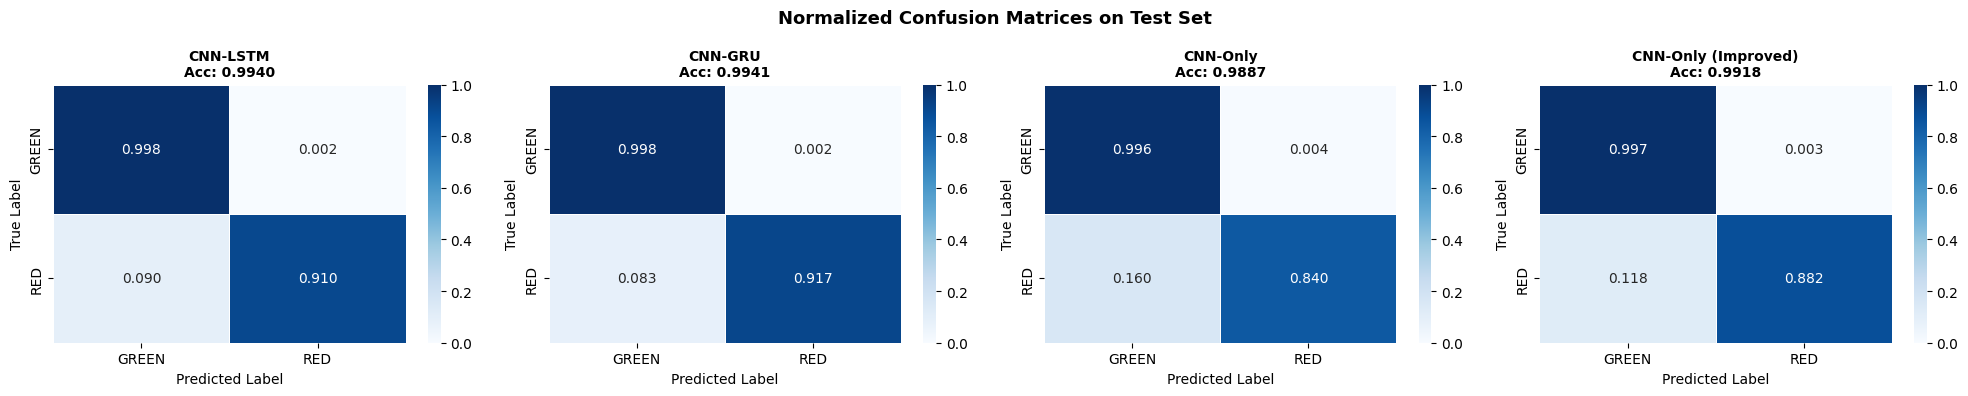

In [ ]:
# ─── Confusion Matrices — all 4 final models ──────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (model_name, r) in zip(axes, results_summary.items()):
    cm = r['cm_norm']
    sns.heatmap(cm, annot=True, fmt='.3f', ax=ax, cmap='Blues',
                vmin=0, vmax=1,
                xticklabels=['GREEN', 'RED'],
                yticklabels=['GREEN', 'RED'],
                linewidths=0.5, linecolor='white')
    ax.set_title(
        f"{model_name}\nAcc: {r['test_acc']:.4f}",
        fontweight='bold', fontsize=10
    )
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Normalized Confusion Matrices on Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_keras.png', dpi=150, bbox_inches='tight')
plt.show()